# Uncertainty Functions

Let's import the necessary libraries.

In [2]:
import brainstate as bst
import numpy as np
import pinnx

Define the geometry of the problem domain.

In [3]:
geom = pinnx.geometry.Interval(-1, 1)

Set the number of training and testing samples.

In [4]:
num_train = 10
num_test = 1000

Define the function to be approximated.

In [5]:
def func(x):
    """
    x: array_like, N x D_in
    y: array_like, N x D_out
    """
    return x * np.sin(5 * x)

Generate the training and testing data using the defined function and geometry.

In [6]:
data = pinnx.data.Function(geom, func, num_train, num_test)

Initialize the neural network with the specified architecture and activation function.

In [7]:
layer_size = [1] + [50] * 3 + [1]   # Define the architecture of the neural network
net = pinnx.nn.FNN(layer_size, "tanh", bst.init.KaimingUniform())

Create a model using the generated data and the neural network.

In [8]:
model = pinnx.Model(data, net)

Compile the model with an optimizer and metrics for evaluation.

In [9]:
model.compile(bst.optim.Adam(0.001), metrics=["l2 relative error"])

Compiling model...
'compile' took 0.052468 s



Set up a callback for uncertainty estimation using dropout.

In [10]:
uncertainty = pinnx.callbacks.DropoutUncertainty(period=1000)

Train the model for a specified number of iterations with the uncertainty callback.

In [11]:
losshistory, train_state = model.train(iterations=30000, callbacks=uncertainty)

Training model...

Step      Train loss    Test loss     Test metric   
0         [3.31e-01]    [2.58e-01]    [1.13e+00]    
1000      [3.71e-04]    [1.01e-03]    [7.08e-02]    
2000      [2.65e-07]    [8.14e-04]    [6.34e-02]    
3000      [7.67e-09]    [8.05e-04]    [6.30e-02]    
4000      [2.58e-13]    [8.04e-04]    [6.30e-02]    
5000      [1.31e-08]    [7.91e-04]    [6.25e-02]    
6000      [6.17e-14]    [7.89e-04]    [6.24e-02]    
7000      [6.75e-14]    [7.89e-04]    [6.24e-02]    
8000      [1.52e-13]    [7.78e-04]    [6.20e-02]    
9000      [3.99e-14]    [7.78e-04]    [6.20e-02]    
10000     [1.18e-13]    [7.67e-04]    [6.16e-02]    
11000     [2.22e-14]    [7.67e-04]    [6.16e-02]    
12000     [2.30e-11]    [7.65e-04]    [6.15e-02]    
13000     [5.28e-13]    [7.60e-04]    [6.13e-02]    
14000     [7.50e-11]    [7.50e-04]    [6.09e-02]    
15000     [1.72e-14]    [7.50e-04]    [6.09e-02]    
16000     [1.80e-11]    [7.50e-04]    [6.09e-02]    
17000     [2.04e-14]    [7.

Save and plot the training history and state.

Saving loss history to c:\Github\pinnx\docs\function\loss.dat ...
Saving training data to c:\Github\pinnx\docs\function\train.dat ...
Saving test data to c:\Github\pinnx\docs\function\test.dat ...


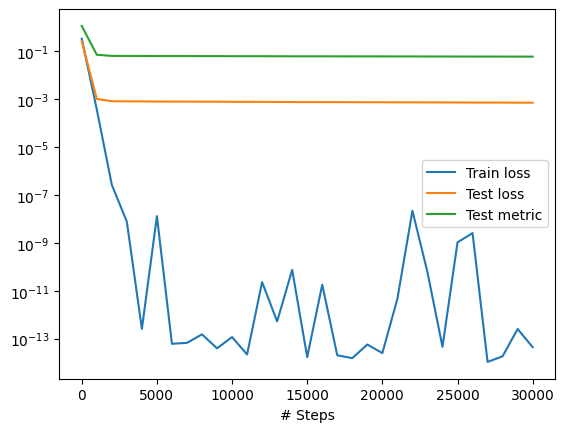

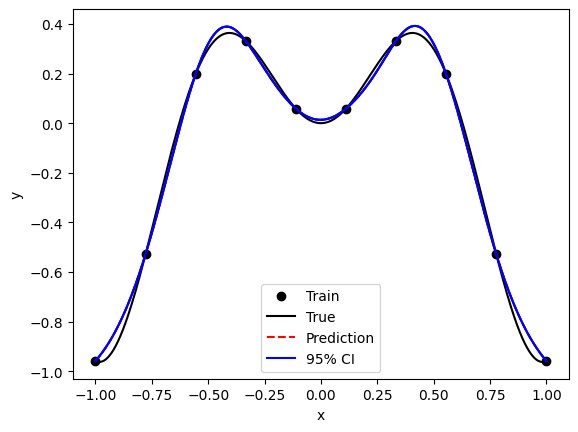

In [12]:
pinnx.saveplot(losshistory, train_state, issave=True, isplot=True)